# Car Price Prediction Project
# Exploratory Data Analysis (EDA)
# Цель проекта:
## Построить ML модель для предсказания стоимости подержанного автомобиля на основе его характеристик.

### В этом ноутбуке выполняется:
 - загрузка данных
 - анализ структуры датасета
 - анализ пропусков
 - поиск выбросов
 - исследование распределений признаков


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# настройки отображения
pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")


## Импорт библиотек

Импортируем необходимые библиотеки для анализа данных: pandas для работы с данными, numpy для численных операций, matplotlib и seaborn для визуализации. Устанавливаем настройки отображения для удобства просмотра.

In [3]:
df = pd.read_csv("../data/raw/all_car_adverts.csv")

df.head()


,Unnamed: 0,make,model,variant,car_price,car_badges,car_title,car_sub_title,car_attention_grabber,car_specs,car_seller,car_seller_rating,car_seller_location,year,reg,body_type,miles,engine_vol,engine_size,engine_size_unit,transmission,feul_type,num_owner,ulez,full_service,part_service,part_warranty,full_dealership,first_year_road_tax,brand_new,finance_available,discounted
0,0,AC,Cobra,NaN,89995.0,NaN,AC Cobra,4.9 MK IV CRS 2dr,GENUINE AC COBRA CRS 522 BHP,"2001 (X reg), Convertible, 14,400 miles, 4.9L,...",Private seller,NaN,watford,2001,X reg,convertible,14400.0,4.9,225.0,bhp,manual,petrol,5.0,0,0,0,0,0,0,0,0,0
1,1,AC,Cobra,NaN,92500.0,'',AC Cobra,378 - MkIV,PHYSICAL CAR!,"2019 (T reg), Convertible, 650 miles, Manual, ...",Boss Motor Company Limited,5.0,chesham,2019,T reg,convertible,650.0,NaN,NaN,NaN,manual,petrol,NaN,0,0,0,0,0,0,0,0,0
2,2,AC,Cobra,NaN,109995.0,'',AC Cobra,MK1V 212 SC. 3.5 V8 350 BHP LOTUS TWIN TURBO. ...,FULL CARBON FIBRE BODY.,"2000 (X reg), Convertible, 21,600 miles, 3.5L,...",PREMIER GT LIMITED,4.8,pulborough,2000,X reg,convertible,21600.0,3.5,NaN,NaN,manual,petrol,3.0,0,0,0,0,0,0,0,0,0
3,3,AC,Cobra,NaN,124950.0,'',AC Cobra,302 MKIV 2dr,ABSOLUTELY STUNNING,"1989 (F reg), Convertible, 2,750 miles, Manual...",TOP 555 LIMITED,5.0,oakham,1989,F reg,convertible,2750.0,NaN,NaN,NaN,manual,petrol,NaN,0,0,0,0,0,0,0,0,0
4,4,AC,Cobra,NaN,124950.0,'',AC Cobra,302 MKIV With Factory Lightweight Engine 5.0 2dr,'STAGE 3' SVO ENGINE,"1989 (E reg), Convertible, 15,142 miles, 5.0L,...",TOP 555 LIMITED,5.0,oakham,1989,E reg,convertible,15142.0,5.0,NaN,NaN,manual,petrol,NaN,0,0,0,0,0,0,0,0,0


## Загрузка данных

Загружаем датасет с объявлениями автомобилей из CSV-файла и выводим первые строки для ознакомления со структурой данных.

In [4]:
df.shape


(818456, 32)

## Размер датасета

Определяем количество строк и столбцов в датасете.

In [5]:
df.columns


Index(['Unnamed: 0', 'make', 'model', 'variant', 'car_price', 'car_badges',
       'car_title', 'car_sub_title', 'car_attention_grabber', 'car_specs',
       'car_seller', 'car_seller_rating', 'car_seller_location', 'year', 'reg',
       'body_type', 'miles', 'engine_vol', 'engine_size', 'engine_size_unit',
       'transmission', 'feul_type', 'num_owner', 'ulez', 'full_service',
       'part_service', 'part_warranty', 'full_dealership',
       'first_year_road_tax', 'brand_new', 'finance_available', 'discounted'],
      dtype='object')

## Названия столбцов

Выводим названия всех столбцов датасета.

In [6]:
df.columns.tolist()


['Unnamed: 0',
 'make',
 'model',
 'variant',
 'car_price',
 'car_badges',
 'car_title',
 'car_sub_title',
 'car_attention_grabber',
 'car_specs',
 'car_seller',
 'car_seller_rating',
 'car_seller_location',
 'year',
 'reg',
 'body_type',
 'miles',
 'engine_vol',
 'engine_size',
 'engine_size_unit',
 'transmission',
 'feul_type',
 'num_owner',
 'ulez',
 'full_service',
 'part_service',
 'part_warranty',
 'full_dealership',
 'first_year_road_tax',
 'brand_new',
 'finance_available',
 'discounted']

## Список столбцов

Получаем список названий столбцов в виде списка Python.

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818456 entries, 0 to 818455
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             818456 non-null  int64  
 1   make                   818456 non-null  object 
 2   model                  818153 non-null  object 
 3   variant                816207 non-null  object 
 4   car_price              818456 non-null  float64
 5   car_badges             801459 non-null  object 
 6   car_title              818456 non-null  object 
 7   car_sub_title          817909 non-null  object 
 8   car_attention_grabber  738163 non-null  object 
 9   car_specs              818456 non-null  object 
 10  car_seller             818348 non-null  object 
 11  car_seller_rating      644191 non-null  float64
 12  car_seller_location    816256 non-null  object 
 13  year                   818456 non-null  object 
 14  reg                    747436 non-nu

## Информация о датасете

Выводим общую информацию о датасете: количество строк, столбцов, типы данных, наличие пропусков.

In [8]:
df.describe()


,Unnamed: 0,car_price,car_seller_rating,miles,engine_vol,engine_size,num_owner,ulez,full_service,part_service,part_warranty,full_dealership,first_year_road_tax,brand_new,finance_available,discounted
count,818456.000000,8.184560e+05,644191.000000,763703.000000,803010.000000,814247.000000,442596.000000,818456.000000,818456.000000,818456.000000,818456.000000,818456.000000,818456.000000,818456.000000,818456.000000,818456.000000
mean,409227.500000,2.011859e+04,4.649465,48735.854328,1.860284,170.134123,2.097290,0.815449,0.108105,0.013059,0.063693,0.035079,0.063693,0.066233,0.716983,0.045162
std,236268.040297,2.224110e+04,0.433626,36520.141907,0.752763,92.141443,1.265622,0.387933,0.310513,0.113526,0.244206,0.183981,0.244206,0.248690,0.450465,0.207659
min,0.000000,3.000000e+02,1.000000,2.000000,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,204613.750000,8.990000e+03,4.600000,19441.000000,1.400000,115.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,409227.500000,1.500000e+04,4.700000,40267.000000,1.600000,148.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,613841.250000,2.450000e+04,4.900000,71215.500000,2.000000,190.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,818455.000000,3.199830e+06,5.000000,999999.000000,8.300000,2460.000000,32.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Статистическое описание числовых признаков

Выводим описательные статистики для числовых столбцов: среднее, медиану, квартили, минимум, максимум.

In [9]:
df.isnull().sum()
missing = df.isnull().sum().sort_values(ascending=False)

missing


num_owner                375860
car_seller_rating        174265
car_attention_grabber     80293
reg                       71020
miles                     54753
car_badges                16997
engine_vol                15446
engine_size                4209
engine_size_unit           4209
variant                    2249
car_seller_location        2200
body_type                   712
car_sub_title               547
model                       303
feul_type                   222
transmission                213
car_seller                  108
car_specs                     0
year                          0
car_title                     0
Unnamed: 0                    0
make                          0
car_price                     0
ulez                          0
full_service                  0
part_service                  0
part_warranty                 0
full_dealership               0
first_year_road_tax           0
brand_new                     0
finance_available             0
discount

## Анализ пропусков

Подсчитываем количество пропусков в каждом столбце и сортируем по убыванию для выявления проблемных признаков.

In [10]:
df.duplicated().sum()

np.int64(0)

## Проверка на дубликаты

Подсчитываем количество дублированных строк в датасете.

In [11]:
df = df.drop_duplicates()


## Удаление дубликатов

Удаляем все дублированные строки из датасета для обеспечения качества данных.

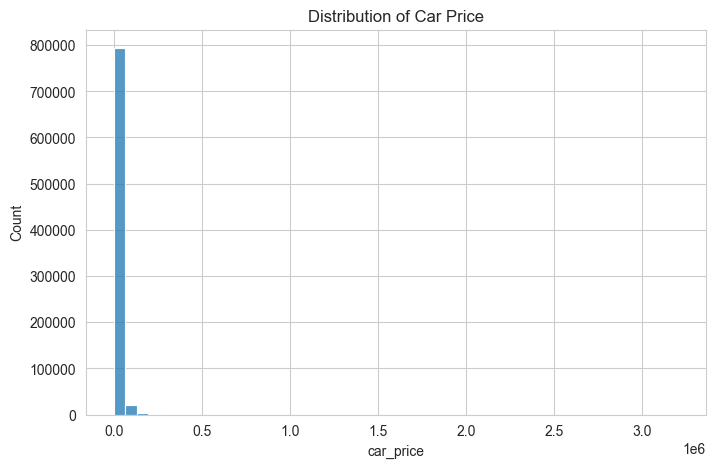

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["car_price"], bins=50)

plt.title("Distribution of Car Price")
plt.show()


## Распределение цен автомобилей

Строим гистограмму распределения цен автомобилей для анализа формы распределения и выявления аномалий.

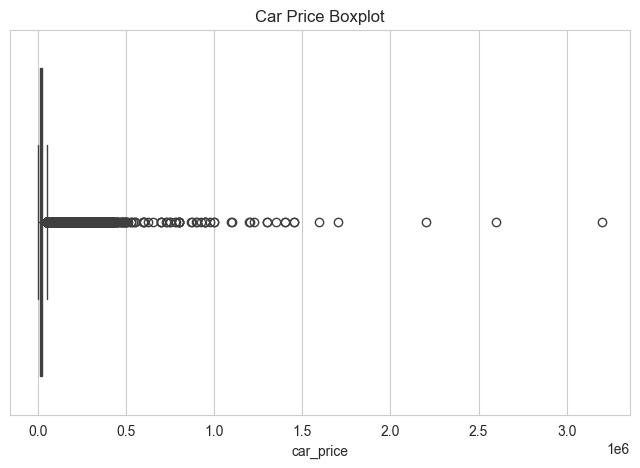

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["car_price"])

plt.title("Car Price Boxplot")
plt.show()


## Boxplot цен автомобилей

Строим boxplot для визуализации квартилей, медианы и выявления выбросов в ценах автомобилей.

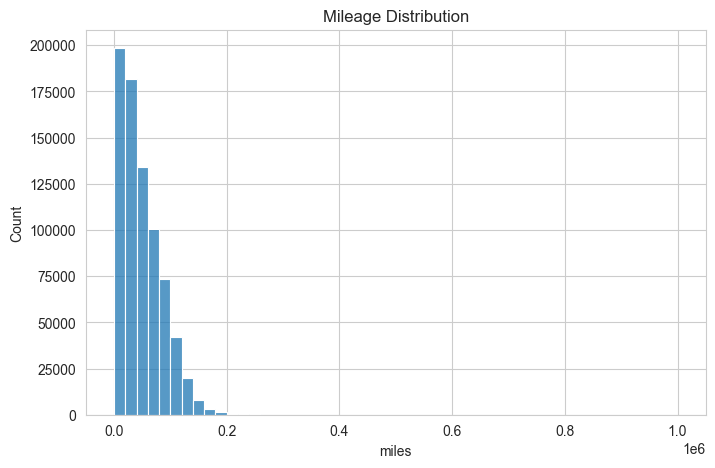

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["miles"], bins=50)

plt.title("Mileage Distribution")
plt.show()


## Распределение пробега

Строим гистограмму распределения пробега автомобилей для анализа типичных значений и формы распределения.

In [15]:
# извлекаем только 4-значные годы
df["year"] = df["year"].str.extract(r"(\d{4})")

df["year"] = pd.to_numeric(df["year"])


df = df.dropna(subset=["year"])

df["year"] = df["year"].astype(int)

df = df[(df["year"] >= 1980) & (df["year"] <= 2024)]

## Обработка столбца year

Извлекаем год из строки, конвертируем в числовой тип, удаляем пропуски и фильтруем автомобили с 1980 по 2024 год.

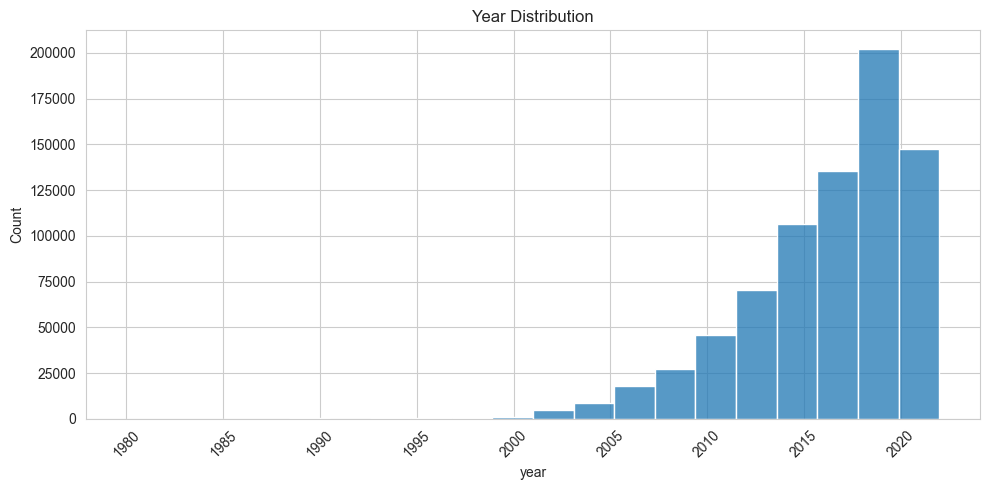

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df["year"], bins=20)

plt.title("Year Distribution")

years = sorted(df["year"].unique())
plt.xticks(range(min(years), max(years)+1, 5), rotation=45)

plt.tight_layout()

plt.show()

## Распределение годов выпуска

Строим гистограмму распределения годов выпуска автомобилей для анализа возрастного состава датасета.

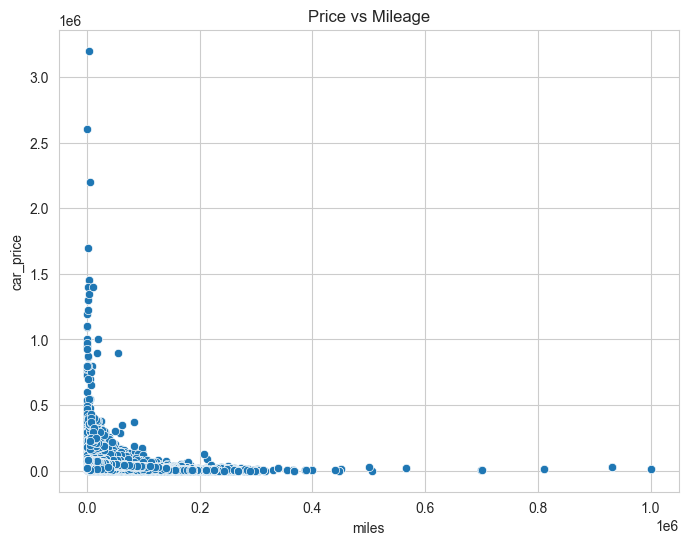

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["miles"],
    y=df["car_price"]
)

plt.title("Price vs Mileage")
plt.show()


## Связь цены и пробега

Строим scatter plot для анализа взаимосвязи между ценой автомобиля и его пробегом.

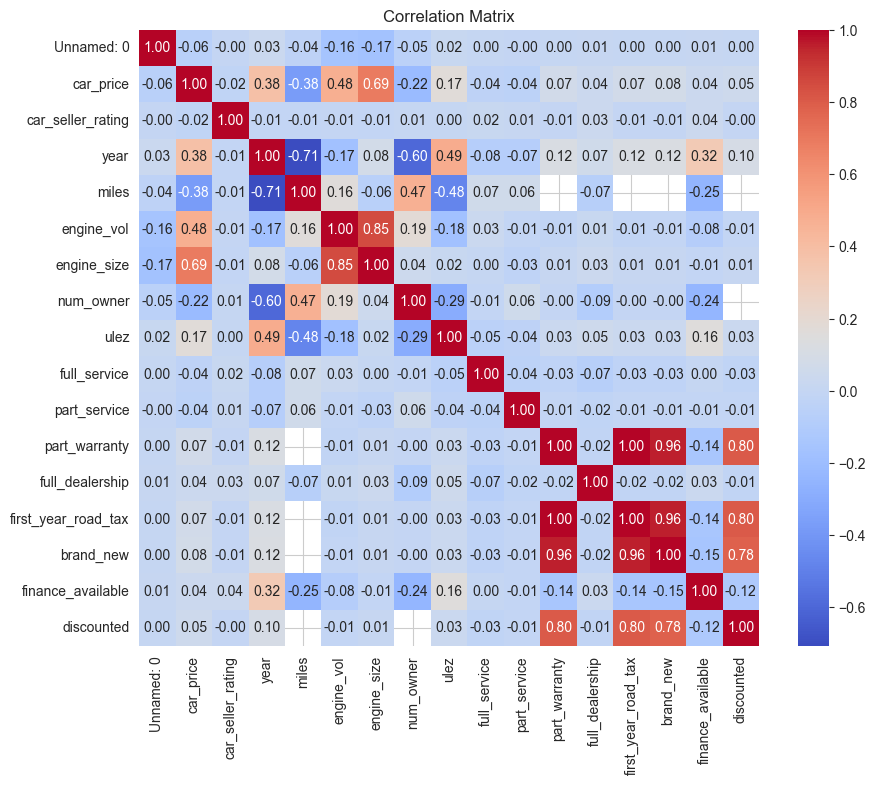

In [18]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size":10}
)

plt.title("Correlation Matrix")

plt.show()

## Корреляционная матрица

Строим heatmap корреляционной матрицы для числовых признаков, чтобы выявить линейные взаимосвязи между переменными.

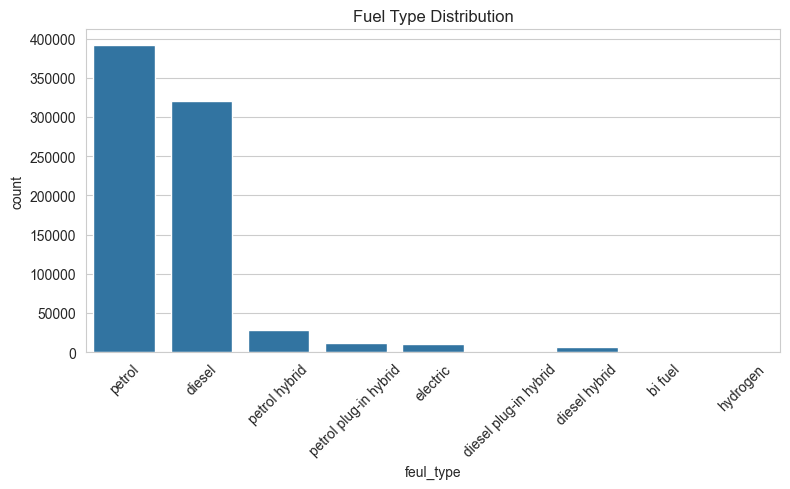

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["feul_type"])

plt.title("Fuel Type Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Распределение типов топлива

Строим countplot для анализа распределения автомобилей по типам топлива.

<Axes: xlabel='make'>

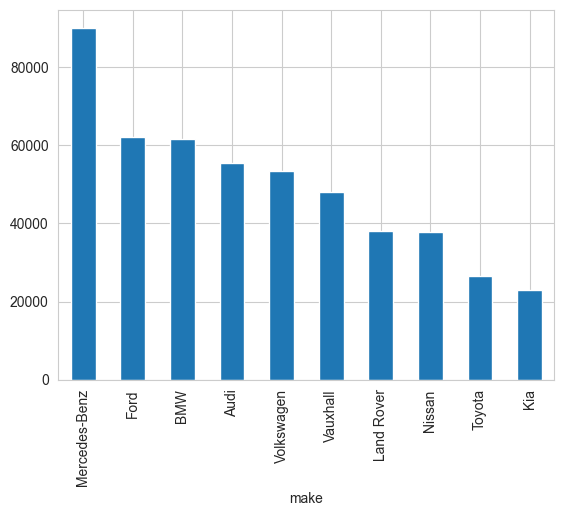

In [20]:
df["make"].value_counts().head(10).plot(kind="bar") 

## Выводы по EDA

В результате разведочного анализа данных были получены следующие ключевые insights:

### Структура данных:
- Датасет содержит объявления о продаже подержанных автомобилей
- После удаления дубликатов и фильтрации по году выпуска осталось значимое количество наблюдений
- Данные включают как числовые (цена, пробег, год), так и категориальные признаки (марка, тип топлива)

### Качество данных:
- Обнаружены пропуски в различных столбцах, требующие обработки
- Присутствуют дубликаты, которые были удалены
- Выявлены выбросы в ценах автомобилей

### Распределения признаков:
- **Цена**: скошенное распределение с длинным правым хвостом, присутствуют дорогие автомобили
- **Пробег**: типичное распределение с пиком в районе средних значений
- **Год выпуска**: большинство автомобилей относительно новые (после 2010 года)
- **Тип топлива**: преобладают бензиновые и дизельные автомобили

### Взаимосвязи:
- Отрицательная корреляция между ценой и пробегом (что логично)
- Корреляция между ценой и годом выпуска (новые автомобили дороже)
- Возможны другие значимые взаимосвязи, требующие дальнейшего исследования

### Рекомендации для следующего этапа:
1. Обработать пропуски в данных
2. Рассмотреть удаление или обработку выбросов
3. Создать новые признаки (возраст автомобиля, категории пробега и т.д.)
4. Провести feature engineering для категориальных переменных
5. Дальнейший анализ взаимосвязей и отбор признаков

Эти insights послужат основой для этапа feature engineering и построения модели предсказания цен.

## Топ-10 марок автомобилей

Строим столбчатую диаграмму для 10 наиболее популярных марок автомобилей в датасете.